In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [8]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [9]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\4076636688.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\4076636688.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\4076636688.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

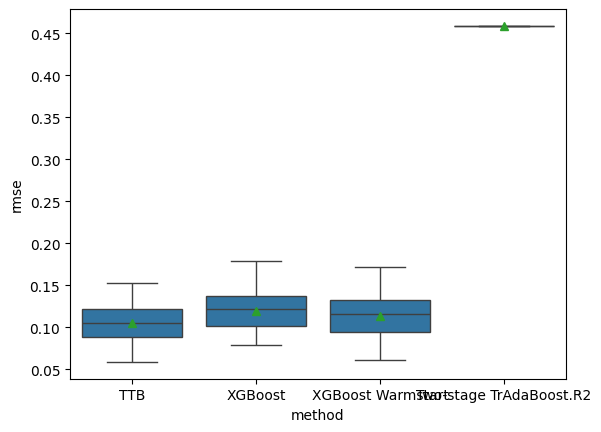

In [10]:
sub_name = 'species'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'n_estimators_fs', 'cv'], k=nr_of_seeds
)
best_trada['method'] = 'Two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [11]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'n_estimators_fs', 'cv'], k=100000
)
best_trada['method'] = 'Two-stage TrAdaBoost.R2'



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\761470868.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\761470868.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\761470868.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [12]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
398,0.1,2.0,2.0,0.00,0.5,0.105320,0.075727,30,865.0,400.0,0.075968,0.048787,0.127936,0.092311,TransferTreeBoost
579,0.1,2.0,1.0,0.01,0.5,0.105464,0.074106,30,868.0,400.0,0.101702,0.080389,0.118754,0.079636,TransferTreeBoost
303,0.1,2.0,1.0,0.05,0.9,0.106000,0.073261,30,864.0,400.0,0.063925,0.051438,0.138197,0.098642,TransferTreeBoost
284,0.1,1.0,1.0,0.01,0.9,0.106014,0.075540,30,863.0,400.0,0.095329,0.064652,0.083513,0.064425,TransferTreeBoost
1659,0.1,1.0,2.0,0.01,0.9,0.106112,0.077015,30,883.0,400.0,0.141783,0.093747,0.123841,0.088058,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,0.1,1.0,1.0,0.05,0.1,0.116099,0.080458,30,860.0,400.0,0.122685,0.089679,0.090983,0.066386,TransferTreeBoost
949,0.1,1.0,2.0,0.05,0.1,0.116531,0.080566,30,873.0,400.0,0.129052,0.092865,0.113211,0.080380,TransferTreeBoost
1810,0.1,1.0,3.0,0.01,0.1,0.120148,0.085870,30,885.0,400.0,0.122439,0.089270,0.081187,0.062393,TransferTreeBoost
93,0.1,1.0,3.0,0.05,0.1,0.121806,0.086720,30,861.0,400.0,0.102099,0.058000,0.130079,0.088637,TransferTreeBoost


In [13]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
527,0.20,2.0,0.119331,0.084177,30,523,874.0,0.096745,0.075135,0.101410,0.076588,XGBoost
381,0.25,2.0,0.119600,0.083969,30,385,870.0,0.112254,0.073466,0.173595,0.115226,XGBoost
375,0.15,1.0,0.120101,0.085543,30,372,870.0,0.113426,0.080406,0.178573,0.118632,XGBoost
6,0.10,1.0,0.120186,0.084941,30,6,860.0,0.128682,0.097652,0.113932,0.086530,XGBoost
621,0.20,1.0,0.120506,0.085501,30,630,877.0,0.146496,0.105199,0.131831,0.090053,XGBoost
121,0.15,2.0,0.120536,0.085054,30,121,863.0,0.117902,0.069560,0.104913,0.077174,XGBoost
543,0.05,1.0,0.120621,0.085734,30,540,875.0,0.126312,0.089366,0.111870,0.079894,XGBoost
1067,0.10,2.0,0.120666,0.084813,30,1051,889.0,0.198598,0.128257,0.107711,0.068127,XGBoost
818,0.05,2.0,0.120897,0.085313,30,793,882.0,0.103484,0.077655,0.089431,0.071243,XGBoost
220,0.30,2.0,0.120902,0.085659,30,247,866.0,0.104150,0.072872,0.121949,0.086910,XGBoost


In [14]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
19,0.15,1.0,0.113820,0.079800,30,12,860.0,0.105552,0.075804,0.070465,0.053319,XGBoost Warmstart
308,0.05,1.0,0.113939,0.078829,30,288,868.0,0.101045,0.080153,0.123551,0.090776,XGBoost Warmstart
850,0.10,1.0,0.114299,0.079095,30,834,883.0,0.114337,0.077206,0.125498,0.083858,XGBoost Warmstart
314,0.30,1.0,0.114441,0.081798,30,318,868.0,0.099082,0.079669,0.133876,0.102233,XGBoost Warmstart
955,0.25,1.0,0.114897,0.081263,30,960,886.0,0.083194,0.062405,0.073701,0.055102,XGBoost Warmstart
13,0.20,1.0,0.115496,0.081538,30,18,860.0,0.108928,0.079764,0.075204,0.057396,XGBoost Warmstart
864,0.10,2.0,0.116605,0.079946,30,871,884.0,0.077353,0.052422,0.095546,0.068966,XGBoost Warmstart
725,0.15,2.0,0.117054,0.080932,30,733,880.0,0.134186,0.100306,0.086659,0.053730,XGBoost Warmstart
853,0.05,2.0,0.117127,0.079831,30,829,883.0,0.123284,0.079269,0.144859,0.092822,XGBoost Warmstart
12,0.20,2.0,0.117344,0.081296,30,19,860.0,0.114326,0.087984,0.077760,0.058912,XGBoost Warmstart


In [15]:
#Get best params in order
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,n_estimators_fs,cv,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,rmse,mae,method
0,0.1,10.0,10.0,5.0,0.458871,0.35572,1,0,860.0,0.458871,0.35572,two-stage TrAdaBoost.R2


In [16]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(11.740698121839683)

In [17]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\1121400017.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\1121400017.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_16720\1121400017.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind